In [1]:
from __future__ import division
import pandas as pd
import numpy as np
import time
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator

from matplotlib.ticker import FormatStrFormatter

import scipy.stats as sstat
import scipy.signal as ssig
import h5py
from mpl_toolkits.mplot3d import Axes3D
import os
from sklearn import preprocessing
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA as sklearnPCA
import re

# import ephys_unit_analysis as ena
import mz_ephys_unit_analysis as mz_ena

#import resampy
import fnmatch
import seaborn as sns
%matplotlib inline
%load_ext autoreload
%autoreload 2
mpl.rcParams['pdf.fonttype'] = 42 
mpl.rcParams['font.sans-serif']=['Arial', 'Helvetica','Bitstream Vera Sans', 'DejaVu Sans', 'Lucida Grande', 
                                 'Verdana', 'Geneva', 'Lucid', 'Avant Garde', 'sans-serif']  

sns.despine()

<Figure size 432x288 with 0 Axes>

In [2]:
# for publication quality plots
def set_pub_plots(pal=sns.blend_palette(["gray","crimson", 'cyan', 'magenta', 'purple'  ],5)):
    sns.set_style("white")
    sns.set_palette(pal)
    sns.set_context("poster", font_scale=1.5, rc={"lines.linewidth": 2.5, "axes.linewidth":2.5, 'figure.facecolor': 'white'}) 
    sns.set_style("ticks", {"xtick.major.size": 8, "ytick.major.size": 8})
    plt.rcParams['axes.linewidth'] = 2.5

rc_pub={'font.size': 25, 'axes.labelsize': 25, 'legend.fontsize': 25.0, 
        'axes.titlesize': 25, 'xtick.labelsize': 25, 'ytick.labelsize': 25, 
        'axes.linewidth':2.5, 'lines.linewidth': 2.5,
        'xtick.color': 'black', 'ytick.color': 'black', 'axes.edgecolor': 'black',
        'axes.labelcolor':'black','text.color':'black'}
# to restore the defaults, call plt.rcdefaults() 

set_pub_plots()

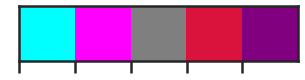

In [3]:
pal=sns.blend_palette(['cyan', 'magenta','gray','crimson','purple'], 5)
sns.palplot(pal)
sns.set_palette(pal)

---

# First, load in the previously saved dataFrame

In [54]:
df_choice = input('Which dataFrame (novel, 1sec, 2sec): ')

if df_choice == 'novel':
    final_df = pd.read_pickle(r"D:\mz_Data\saved_dfs\Operant_reward\novel_1sec_psth.pkl")
elif df_choice == '1sec':
#     final_df = pd.read_pickle(r"D:\mz_Data\saved_dfs\Operant_reward\operant_1sec_psth.pkl") #original df
#     final_df = pd.read_pickle(r"D:\mz_Data\saved_dfs\Operant_reward\operant_1sec_psth_v2.pkl") #all units, new region borders
    final_df = pd.read_pickle(r"D:\mz_Data\saved_dfs\Operant_reward\operant_1sec_psth_v3.pkl") #good units, new region borders
elif df_choice == '2sec':
    final_df = pd.read_pickle(r"D:\mz_Data\saved_dfs\Operant_reward\operant_2sec_psth.pkl")
else:
    raise ValueError('Incorrect input, try again...')

Which dataFrame (novel, 1sec, 2sec): novel


In [55]:
final_df.columns

Index(['times', 'cuid', 'depth', 'Hz', 'zscore', 'ztc', 'region', 'group',
       'set', 'cc', 'et', 'cluster_id', 'path'],
      dtype='object')

In [56]:
print(final_df.et.nunique())
print(final_df.group.unique())
print(final_df.set.unique())
print(final_df.region.unique())

16
['B' 'A']
['1' '2']
['thal' 'v1' 'hippo' 'none']


---

# Subplot unit heatmaps (group separated)

In [57]:
brain_region = input('What brain region (v1, hippo, thal): ')

if df_choice == 'novel':
    # for non-reward
    V1_all_groups_df = final_df[final_df['region'] == brain_region]
    V1_A = V1_all_groups_df[V1_all_groups_df['group'] == 'A']
    V1_B = V1_all_groups_df[V1_all_groups_df['group'] == 'B']
    plt_title = 'Novel'
elif (df_choice == '1sec') | (df_choice == '2sec'):
    rew_to_plot = input('What reward training stage (rew, rew2, unrew): ')
    if rew_to_plot == 'rew':
        reward_df = final_df[final_df['stim_id'] == 0]
        plt_title = 'Rewarded with water'
    elif rew_to_plot == 'rew2':
        reward_df = final_df[final_df['stim_id'] == 1]
        plt_title = 'Rewarded without water'
    elif rew_to_plot == 'unrew':
        reward_df = final_df[final_df['stim_id'] == 2]
        plt_title = 'Unrewarded'
    V1_all_groups_df = reward_df[reward_df['region'] == brain_region]
    V1_A = reward_df[(reward_df['region'] == brain_region) & (reward_df['group'] == 'A')]
    V1_B = reward_df[(reward_df['region'] == brain_region) & (reward_df['group'] == 'B')]
else:
    raise ValueError('Incorrect input, try again...')

What brain region (v1, hippo, thal): hippo


In [58]:
is_sorted = input('Do you want sorted units (yes, no): ')

A_hm1 = V1_A.pivot('cuid', 'times', 'zscore')
B_hm1 = V1_B.pivot('cuid', 'times', 'zscore')

if is_sorted == 'yes':
    A_hm1_np = A_hm1.values[ np.argsort(np.mean(A_hm1.values[:,50:70], axis = 1) )] #if I want sorted activity
    B_hm1_np = B_hm1.values[ np.argsort(np.mean(B_hm1.values[:,50:70], axis = 1) )] #if I want sorted activity
elif is_sorted == 'no':
    A_hm1_np = A_hm1.values
    B_hm1_np = B_hm1.values

Do you want sorted units (yes, no): yes


# Finally, plot it

In [59]:
sp_dims = (15, 6) #(width, height)
v_max = 4
v_min = -1
xvalues = np.arange(start=0, stop=3, step=0.5)
y_min = -2
y_max = 6

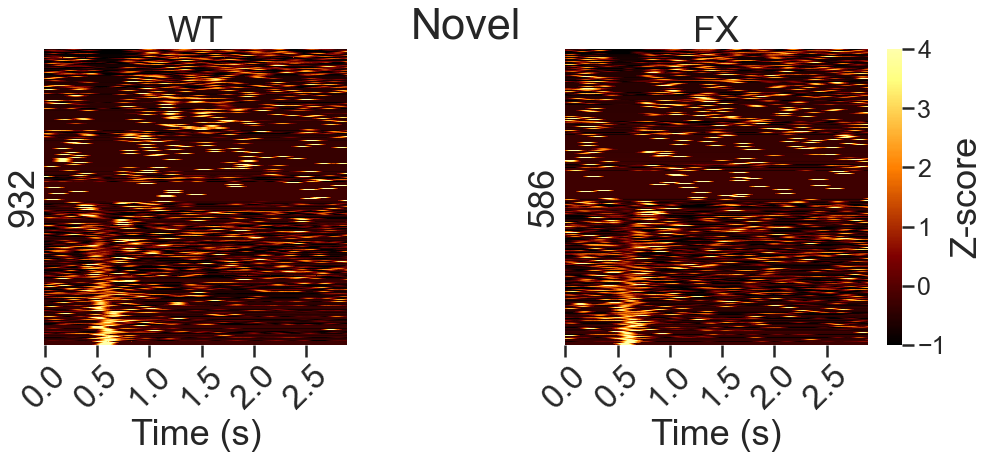

In [60]:
f, (ax1, ax2) = plt.subplots(1,2, sharex='col', figsize=sp_dims)
f.tight_layout()
f.suptitle(plt_title)

# Heatmap for A
sns.heatmap(A_hm1_np, cmap = 'afmhot', xticklabels=50, yticklabels=False, 
                 vmax=v_max, center = 2, vmin = v_min, robust = True, ax=ax1)
ax1.set_xlabel('Time (s)')
ax1.set_ylabel(str(len(V1_A.cuid.unique())))
ax1.set_xticklabels(xvalues, rotation=45)
ax1.set_xlim(0,2.9*100)
ax1.set_title('WT')
cbar = ax1.collections[0].colorbar
cbar.remove()

#Heatmap for B
sns.heatmap(B_hm1_np, cmap = 'afmhot', xticklabels=50, yticklabels=False, 
                 vmax=v_max, center = 2, vmin = v_min, robust = True, ax=ax2)
ax2.set_xlabel('Time (s)')
ax2.set_ylabel(str(len(V1_B.cuid.unique())))
ax2.set_xticklabels(xvalues, rotation=45)
ax2.set_xlim(0,2.9*100)
ax2.set_title('FX')
cbar = ax2.collections[0].colorbar
cbar.ax.tick_params(labelsize=25)
cbar.set_label('Z-score')


# Change the end of this next line with a new file name!!
# plt.savefig(r"D:\mz_Data\DATA_Figs\Operant_Reward\units\unrew_heat_V1.pdf", transparent=True)

plt.show()

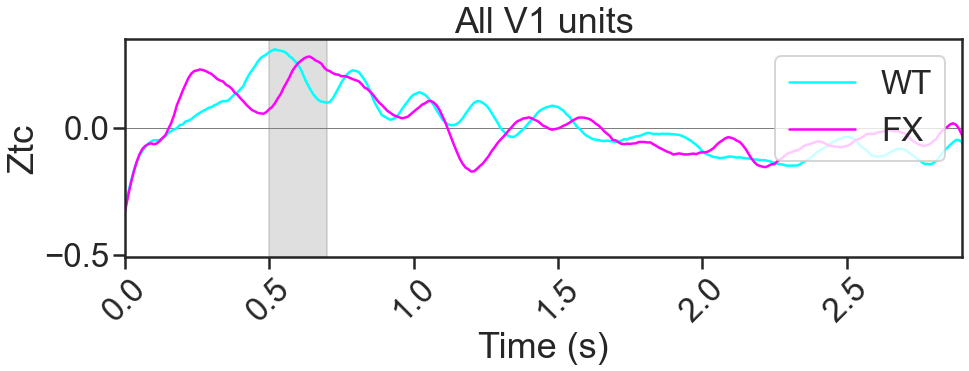

In [61]:
#Combined lineplot
sns.lineplot(x = 'times', y = 'zscore', 
             estimator = 'mean', 
             data = V1_all_groups_df, 
             hue = 'group',
             hue_order=['A','B'],
             palette=sns.color_palette(['cyan', 'magenta']),
             legend=False,
             ci=None) #ci is the error

plt.legend(['WT','FX'], loc="upper right")
plt.axhline(y=0, xmin=0, xmax=3, c='black', linewidth=0.5, zorder=0)
plt.axvspan(0.5,0.7, color='Gray', alpha=0.25)
plt.tick_params(axis='x', rotation=45)
# plt.set_ylim(-2,16)
plt.xlim(0,2.9)
plt.xticks([0,0.5,1,1.5,2,2.5])
plt.xlabel('Time (s)')
plt.ylabel('Ztc')
plt.title('All V1 units')

# Change the end of this next line with a new file name!!
# plt.savefig(r"D:\mz_Data\DATA_Figs\Operant_Reward\units\unrew_line_V1.pdf", transparent=True)

plt.show()

---

# Big plot of all situations

In [62]:
def create_needed_dfs(reward_df, region='v1', is_sorted='yes'):
    all_df = reward_df[reward_df['region'] == region]
    
    V1_A = reward_df[(reward_df['region'] == region) & (reward_df['group'] == 'A')]
    V1_B = reward_df[(reward_df['region'] == region) & (reward_df['group'] == 'B')]
    
    A_num_units = len(V1_A.cuid.unique())
    B_num_units = len(V1_B.cuid.unique())
    
    A_hm1 = V1_A.pivot('cuid', 'times', 'zscore')
    B_hm1 = V1_B.pivot('cuid', 'times', 'zscore')
    
    if is_sorted == 'yes':
        A_hm1_np = A_hm1.values[ np.argsort(np.mean(A_hm1.values[:,50:70], axis = 1) )] #if I want sorted activity
        B_hm1_np = B_hm1.values[ np.argsort(np.mean(B_hm1.values[:,50:70], axis = 1) )] #if I want sorted activity
    else:
        A_hm1_np = A_hm1.values
        B_hm1_np = B_hm1.values
    
    return all_df, A_hm1_np, B_hm1_np, A_num_units, B_num_units

In [63]:
v_max = 4
v_min = -1
xvalues = np.arange(start=0, stop=3, step=0.5)
y_min = -2
y_max = 6

# my_region = 'v1'
my_region = 'hippo'
# my_region = 'thal'

my_sort = 'yes' # this sorts the units in the function defined above ^, 'yes' or 'no'

In [64]:
if df_choice == 'novel':    
    novel_all, novel_A, novel_B, novel_uA, novel_uB = create_needed_dfs(final_df, region=my_region, is_sorted=my_sort)

elif (df_choice == '1sec') | (df_choice == '2sec'):   
    V1_all_groups_df = reward_df[reward_df['region'] == my_region] #this is used for the combo line plot

    rew_df = final_df[final_df['stim_id'] == 0]
    rew2_df = final_df[final_df['stim_id'] == 1]
    unrew_df = final_df[final_df['stim_id'] == 2]

    rew_all, rew_A, rew_B, rew_uA, rew_uB = create_needed_dfs(rew_df, region=my_region, is_sorted=my_sort)
    rew2_all, rew2_A, rew2_B, rew2_uA, rew2_uB = create_needed_dfs(rew2_df, region=my_region, is_sorted=my_sort)
    unrew_all, unrew_A, unrew_B, unrew_uA, unrew_uB = create_needed_dfs(unrew_df, region=my_region, is_sorted=my_sort)


In [48]:
# plt.rcdefaults()

### if using the rewarded situations

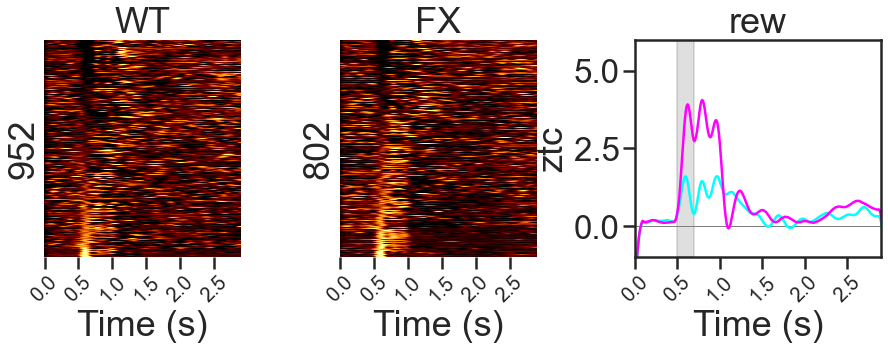

In [53]:
fig_size = plt.rcParams["figure.figsize"]
fig_size[0] = 15.0 # x dimension
fig_size[1] = 4.0 # y dimension


# top left
ax1 = plt.subplot(131)
sns.heatmap(rew_A, cmap = 'afmhot', xticklabels=50, yticklabels=False, 
                 vmax=v_max, center = 2, vmin = v_min, robust = True, ax=ax1)
ax1.set_xlabel('Time (s)')
ax1.set_xticklabels(xvalues, rotation=45, size=20)
ax1.set_xlim(0,2.9*100)
ax1.set_ylabel(str(rew_uA))
ax1.set_xlim(0,2.9*100)
ax1.set_title('WT')
cbar = ax1.collections[0].colorbar
cbar.remove()

# top middle
ax2 = plt.subplot(132, sharex=ax1)
sns.heatmap(rew_B, cmap = 'afmhot', xticklabels=50, yticklabels=False, 
                 vmax=v_max, center = 2, vmin = v_min, robust = True, ax=ax2)
ax2.set_xlabel('Time (s)')
ax2.set_xticklabels(xvalues, rotation=45, size=20)
ax2.set_xlim(0,2.9*100)
ax2.set_ylabel(str(rew_uB))
ax2.set_title('FX')
cbar = ax2.collections[0].colorbar
cbar.remove()

# top right
ax3 = plt.subplot(133)   
sns.lineplot(x = 'times', y = 'ztc', estimator = 'mean', data = rew_all, 
             hue = 'group',hue_order=['A','B'],palette=sns.color_palette(['cyan', 'magenta']),
             legend=False,ci=None) #ci is the error
plt.axhline(y=0, xmin=0, xmax=3, c='black', linewidth=0.5, zorder=0)
plt.axvspan(0.5,0.7, color='Gray', alpha=0.25)
plt.title('rew')
plt.tick_params(axis='x', rotation=45, labelsize=20)
plt.xlim(0,2.9)
plt.xticks([0,0.5,1,1.5,2,2.5])
plt.xlabel('Time (s)')
plt.ylim([-1,6])

# save_folder = r"U:\Data\zimmer94\Operant_Reward\units\hippo"
# overall_path = save_folder + "\\" + "1sec_rew_3plot.pdf"
# plt.savefig(overall_path)

plt.show()
    

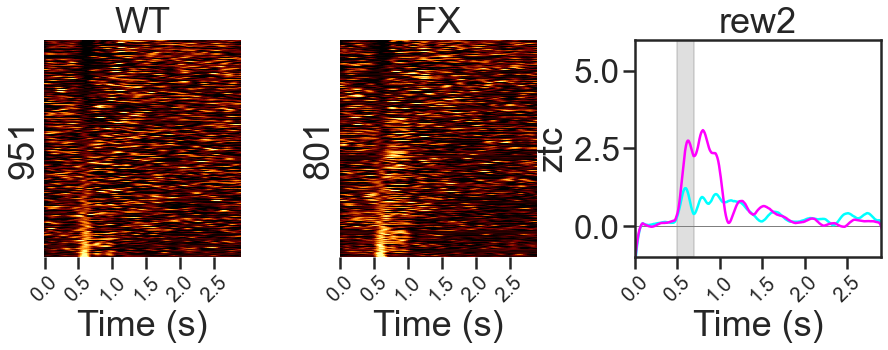

In [50]:
# top left
ax1 = plt.subplot(131)
sns.heatmap(rew2_A, cmap = 'afmhot', xticklabels=50, yticklabels=False, 
                 vmax=v_max, center = 2, vmin = v_min, robust = True, ax=ax1)
ax1.set_xlabel('Time (s)')
ax1.set_xticklabels(xvalues, rotation=45, size=20)
ax1.set_xlim(0,2.9*100)
ax1.set_ylabel(str(rew2_uA))
ax1.set_xlim(0,2.9*100)
ax1.set_title('WT')
cbar = ax1.collections[0].colorbar
cbar.remove()

# top middle
ax2 = plt.subplot(132, sharex=ax1)
sns.heatmap(rew2_B, cmap = 'afmhot', xticklabels=50, yticklabels=False, 
                 vmax=v_max, center = 2, vmin = v_min, robust = True, ax=ax2)
ax2.set_xlabel('Time (s)')
ax2.set_xticklabels(xvalues, rotation=45, size=20)
ax2.set_xlim(0,2.9*100)
ax2.set_ylabel(str(rew2_uB))
ax2.set_title('FX')
cbar = ax2.collections[0].colorbar
cbar.remove()

# top right
ax3 = plt.subplot(133)   
sns.lineplot(x = 'times', y = 'ztc', estimator = 'mean', data = rew2_all, 
             hue = 'group',hue_order=['A','B'],palette=sns.color_palette(['cyan', 'magenta']),
             legend=False,ci=None) #ci is the error
plt.axhline(y=0, xmin=0, xmax=3, c='black', linewidth=0.5, zorder=0)
plt.axvspan(0.5,0.7, color='Gray', alpha=0.25)
plt.title('rew2')
plt.tick_params(axis='x', rotation=45, labelsize=20)
plt.xlim(0,2.9)
plt.xticks([0,0.5,1,1.5,2,2.5])
plt.xlabel('Time (s)')
plt.ylim([-1,6])

# save_folder = r"U:\Data\zimmer94\Operant_Reward\units\hippo"
# overall_path = save_folder + "\\" + "1sec_rew2_3plot.pdf"
# plt.savefig(overall_path)

plt.show()

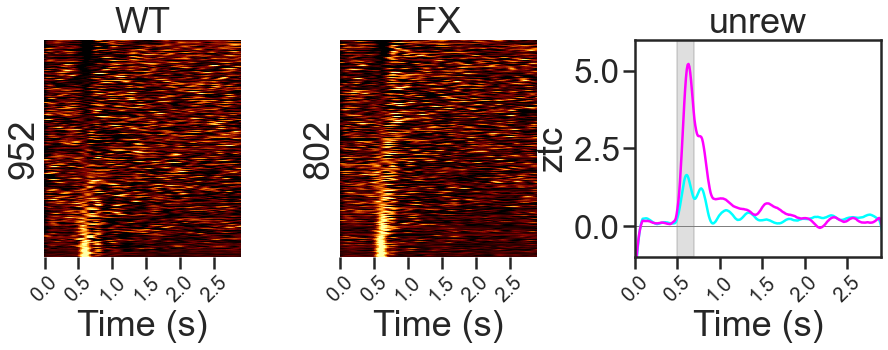

In [51]:
# top left
ax1 = plt.subplot(131)
sns.heatmap(unrew_A, cmap = 'afmhot', xticklabels=50, yticklabels=False, 
                 vmax=v_max, center = 2, vmin = v_min, robust = True, ax=ax1)
ax1.set_xlabel('Time (s)')
ax1.set_xticklabels(xvalues, rotation=45, size=20)
ax1.set_xlim(0,2.9*100)
ax1.set_ylabel(str(unrew_uA))
ax1.set_xlim(0,2.9*100)
ax1.set_title('WT')
cbar = ax1.collections[0].colorbar
cbar.remove()

# top middle
ax2 = plt.subplot(132, sharex=ax1)
sns.heatmap(unrew_B, cmap = 'afmhot', xticklabels=50, yticklabels=False, 
                 vmax=v_max, center = 2, vmin = v_min, robust = True, ax=ax2)
ax2.set_xlabel('Time (s)')
ax2.set_xticklabels(xvalues, rotation=45, size=20)
ax2.set_xlim(0,2.9*100)
ax2.set_ylabel(str(unrew_uB))
ax2.set_title('FX')
cbar = ax2.collections[0].colorbar
cbar.remove()

# top right
ax3 = plt.subplot(133)   
sns.lineplot(x = 'times', y = 'ztc', estimator = 'mean', data = unrew_all, 
             hue = 'group',hue_order=['A','B'],palette=sns.color_palette(['cyan', 'magenta']),
             legend=False,ci=None) #ci is the error
plt.axhline(y=0, xmin=0, xmax=3, c='black', linewidth=0.5, zorder=0)
plt.axvspan(0.5,0.7, color='Gray', alpha=0.25)
plt.title('unrew')
plt.tick_params(axis='x', rotation=45, labelsize=20)
plt.xlim(0,2.9)
plt.xticks([0,0.5,1,1.5,2,2.5])
plt.xlabel('Time (s)')
plt.ylim([-1,6])

# save_folder = r"U:\Data\zimmer94\Operant_Reward\units\hippo"
# overall_path = save_folder + "\\" + "1sec_unrew_3plot.pdf"
# plt.savefig(overall_path)

plt.show()

---

### if using the novel df

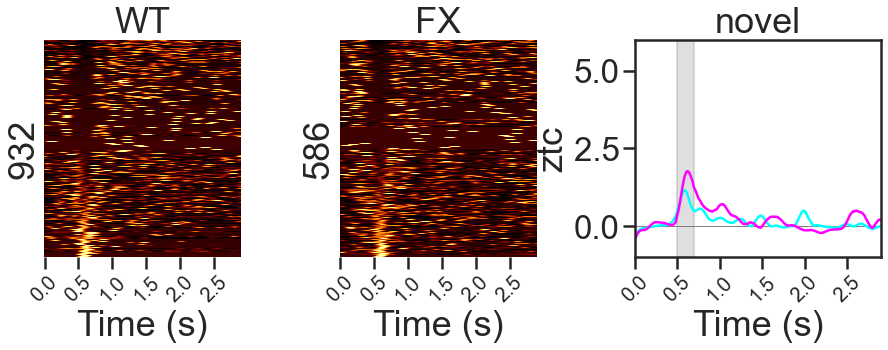

In [67]:
fig_size = plt.rcParams["figure.figsize"]
fig_size[0] = 15.0 # x dimension
fig_size[1] = 4.0 # y dimension


# top left
ax1 = plt.subplot(131)
sns.heatmap(novel_A, cmap = 'afmhot', xticklabels=50, yticklabels=False, 
                 vmax=v_max, center = 2, vmin = v_min, robust = True, ax=ax1)
ax1.set_xlabel('Time (s)')
ax1.set_xticklabels(xvalues, rotation=45, size=20)
ax1.set_xlim(0,2.9*100)
ax1.set_ylabel(str(novel_uA))
ax1.set_xlim(0,2.9*100)
ax1.set_title('WT')
cbar = ax1.collections[0].colorbar
cbar.remove()

# top middle
ax2 = plt.subplot(132, sharex=ax1)
sns.heatmap(novel_B, cmap = 'afmhot', xticklabels=50, yticklabels=False, 
                 vmax=v_max, center = 2, vmin = v_min, robust = True, ax=ax2)
ax2.set_xlabel('Time (s)')
ax2.set_xticklabels(xvalues, rotation=45, size=20)
ax2.set_xlim(0,2.9*100)
ax2.set_ylabel(str(novel_uB))
ax2.set_title('FX')
cbar = ax2.collections[0].colorbar
cbar.remove()

# top right
ax3 = plt.subplot(133)   
sns.lineplot(x = 'times', y = 'ztc', estimator = 'mean', data = novel_all, 
             hue = 'group',hue_order=['A','B'],palette=sns.color_palette(['cyan', 'magenta']),
             legend=False,ci=None) #ci is the error
plt.axhline(y=0, xmin=0, xmax=3, c='black', linewidth=0.5, zorder=0)
plt.axvspan(0.5,0.7, color='Gray', alpha=0.25)
plt.title('novel')
plt.tick_params(axis='x', rotation=45, labelsize=20)
plt.xlim(0,2.9)
plt.xticks([0,0.5,1,1.5,2,2.5])
plt.xlabel('Time (s)')
plt.ylim([-1,6])

# save_folder = r"U:\Data\zimmer94\Operant_Reward\units\hippo"
# overall_path = save_folder + "\\" + "1sec_rew_3plot.pdf"
# plt.savefig(overall_path)

plt.show()

---

In [ ]:
brain_region = input('What brain region (v1, hippo, thal): ')

if df_choice == 'novel':
    # for non-reward
    V1_all_groups_df = final_df[final_df['region'] == brain_region]
    V1_A = V1_all_groups_df[V1_all_groups_df['group'] == 'A']
    V1_B = V1_all_groups_df[V1_all_groups_df['group'] == 'B']
    plt_title = 'Novel'
elif (df_choice == '1sec') | (df_choice == '2sec'):
    rew_to_plot = input('What reward training stage (rew, rew2, unrew): ')
    if rew_to_plot == 'rew':
        reward_df = final_df[final_df['stim_id'] == 0]
        plt_title = 'Rewarded with water'
    elif rew_to_plot == 'rew2':
        reward_df = final_df[final_df['stim_id'] == 1]
        plt_title = 'Rewarded without water'
    elif rew_to_plot == 'unrew':
        reward_df = final_df[final_df['stim_id'] == 2]
        plt_title = 'Unrewarded'
    V1_all_groups_df = reward_df[reward_df['region'] == brain_region]
    V1_A = reward_df[(reward_df['region'] == brain_region) & (reward_df['group'] == 'A')]
    V1_B = reward_df[(reward_df['region'] == brain_region) & (reward_df['group'] == 'B')]
else:
    raise ValueError('Incorrect input, try again...')

In [36]:
is_sorted = input('Do you want sorted units (yes, no): ')

A_hm1 = V1_A.pivot('cuid', 'times', 'zscore')
B_hm1 = V1_B.pivot('cuid', 'times', 'zscore')

if is_sorted == 'yes':
    A_hm1_np = A_hm1.values[ np.argsort(np.mean(A_hm1.values[:,50:70], axis = 1) )] #if I want sorted activity
    B_hm1_np = B_hm1.values[ np.argsort(np.mean(B_hm1.values[:,50:70], axis = 1) )] #if I want sorted activity
elif is_sorted == 'no':
    A_hm1_np = A_hm1.values
    B_hm1_np = B_hm1.values

Do you want sorted units (yes, no): yes


---

# Plotting only the visually responsive units

In [37]:
def vis_resp_units(final_df, region='v1', time_window=[0.5, 0.7], z_score = 2):
    
    test_df = final_df[final_df['region'] == region]
    
    vis_resp = test_df[(test_df['times'] >= time_window[0]) 
                       & (test_df['times'] <= time_window[1]) 
                       & (test_df['zscore'] > z_score)]
    
    test2 = test_df[test_df.cuid.isin(vis_resp.cuid.unique())]
    
    return test2
    

In [38]:
my_region = 'v1'

if df_choice == 'novel':
    vis_resp_df = vis_resp_units(final_df, region=my_region)
    plt_title = 'Novel'
    print('Novel df')
elif (df_choice == '1sec') | (df_choice == '2sec'):
    vis_resp_df = vis_resp_units(reward_df, region=my_region, z_score=1.5)
    print('Reward df')
    if rew_to_plot == 'rew':
        plt_title = 'Rewarded with water'
    elif rew_to_plot == 'rew2':
        plt_title = 'Rewarded without water'
    elif rew_to_plot == 'unrew':
        plt_title = 'Unrewarded'
    print(plt_title)

Reward df
Rewarded with water


In [39]:
plot_A = vis_resp_df[vis_resp_df['group'] == 'A']
plot_B = vis_resp_df[vis_resp_df['group'] == 'B']

test_A = plot_A.pivot('cuid', 'times', 'zscore')
test_A_sort = test_A.values[ np.argsort(np.mean(test_A.values[:,50:70], axis = 1) )] #if I want sorted activity

test_B = plot_B.pivot('cuid', 'times', 'zscore')
test_B_sort = test_B.values[ np.argsort(np.mean(test_B.values[:,50:70], axis = 1) )] #if I want sorted activity



sp_dims = (15, 6) #(width, height)
v_max = 4
v_min = -1
xvalues = np.arange(start=0, stop=3, step=0.5)
y_min = -2
y_max = 6


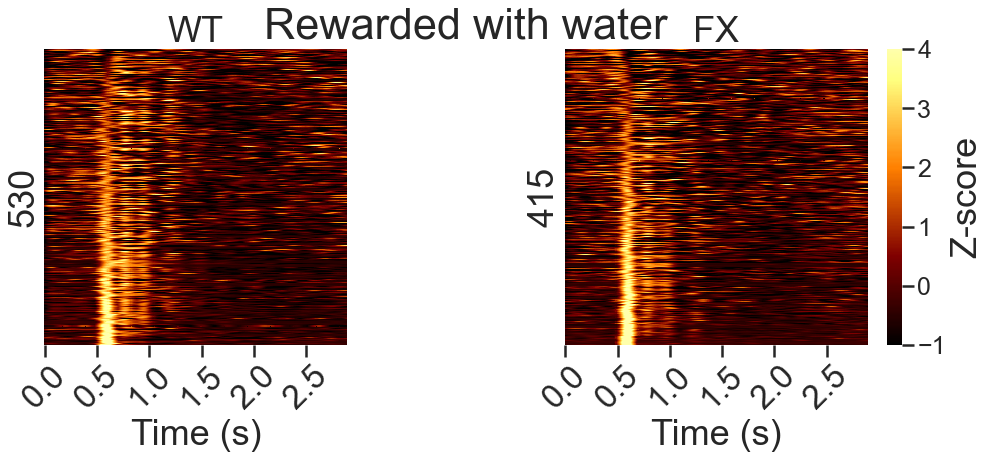

In [40]:
f, (ax1, ax2) = plt.subplots(1,2, sharex='col', figsize=sp_dims)
f.tight_layout()
f.suptitle(plt_title)

# Heatmap for A
sns.heatmap(test_A_sort, cmap = 'afmhot', xticklabels=50, yticklabels=False, 
                 vmax=v_max, center = 2, vmin = v_min, robust = True, ax=ax1)
ax1.set_xlabel('Time (s)')
ax1.set_ylabel(str(len(plot_A.cuid.unique())))
ax1.set_xticklabels(xvalues, rotation=45)
ax1.set_xlim(0,2.9*100)
ax1.set_title('WT')
cbar = ax1.collections[0].colorbar
cbar.remove()

#Heatmap for B
sns.heatmap(test_B_sort, cmap = 'afmhot', xticklabels=50, yticklabels=False, 
                 vmax=v_max, center = 2, vmin = v_min, robust = True, ax=ax2)
ax2.set_xlabel('Time (s)')
ax2.set_ylabel(str(len(plot_B.cuid.unique())))
ax2.set_xticklabels(xvalues, rotation=45)
ax2.set_xlim(0,2.9*100)
ax2.set_title('FX')
cbar = ax2.collections[0].colorbar
cbar.ax.tick_params(labelsize=25)
cbar.set_label('Z-score')

# Change the end of this next line with a new file name!!
# plt.savefig(r"U:\Grants\FX Predictive Coding R01 - Renewal\Preliminary Data Figures\Neuropixels\units\visually responsive\vr_novel_heat.pdf", transparent=True)

plt.show()

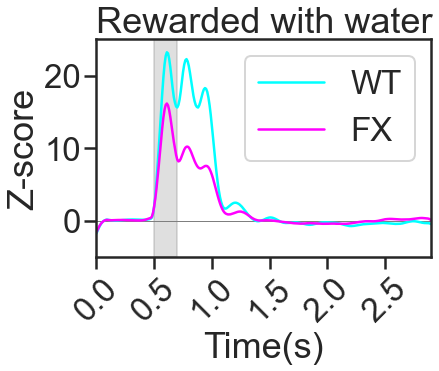

In [43]:
# Lineplot
sns.lineplot(x = 'times', y = 'ztc', 
             estimator = 'mean', 
             data = vis_resp_df, 
             hue = 'group',
             hue_order=['A','B'],
             palette=sns.color_palette(['cyan', 'magenta']),
             legend=False,
             ci=None) #ci is the error

plt.legend(['WT','FX'], loc="upper right")

plt.title(plt_title)
plt.axhline(y=0, xmin=0, xmax=3, c='black', linewidth=0.5, zorder=0)
plt.axvspan(0.5,0.7, color='Gray', alpha=0.25)
plt.tick_params(axis='x', rotation=45)
plt.ylim(-5,25)
plt.xlim(0,2.9)

plt.xticks([0,0.5,1,1.5,2,2.5])
# plt.yticks([-1,0,1,2,3,4])

plt.xlabel('Time(s)')
plt.ylabel('Z-score')

# Change the end of this next line with a new file name!!
# plt.savefig(r"U:\Grants\FX Predictive Coding R01 - Renewal\Preliminary Data Figures\Neuropixels\units\visually responsive\vr_novel_line.pdf", transparent=True)

plt.show()

### same plot as above but groups are separated out

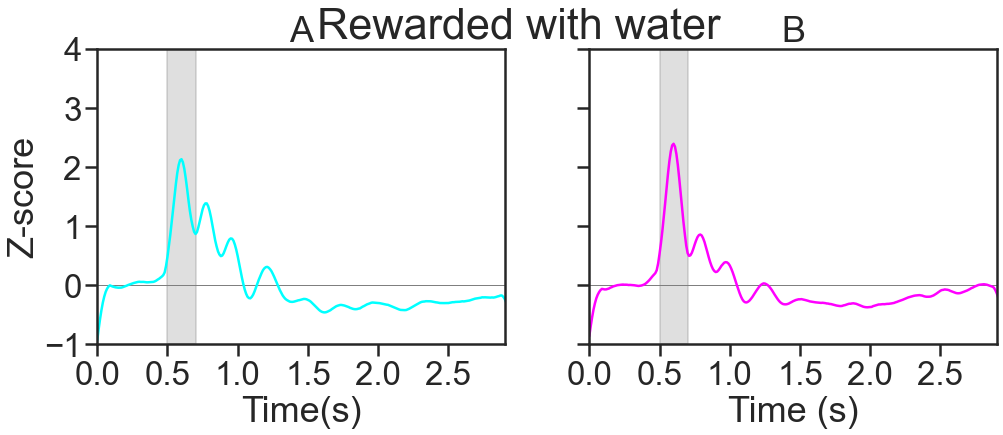

In [42]:
f, (ax1, ax2) = plt.subplots(1,2, sharex='col', sharey=True, figsize=sp_dims)
f.tight_layout()
f.suptitle(plt_title)


# Lineplot
sns.lineplot(x = 'times', y = 'zscore', 
             estimator = 'mean', 
             data = vis_resp_df[vis_resp_df['group'] == 'A'], 
             color='cyan',
             ax=ax1,
             ci=None) #ci is the error
ax1.set_title('A')
ax1.axhline(y=0, xmin=0, xmax=3, c='black', linewidth=0.5, zorder=0)
ax1.axvspan(0.5,0.7, color='Gray', alpha=0.25)
ax1.set_xlim(0,2.9)
ax1.set_xticks([0,0.5,1,1.5,2,2.5])
ax1.set_ylim(-1,4)
ax1.set_yticks([-1,0,1,2,3,4])
ax1.set_xlabel('Time(s)')
ax1.set_ylabel('Z-score')

# Lineplot
sns.lineplot(x = 'times', y = 'zscore', 
             estimator = 'mean', 
             data = vis_resp_df[vis_resp_df['group'] == 'B'],
             color='magenta',
             ax=ax2,
             ci=None) #ci is the error
ax2.set_title('B')
ax2.axhline(y=0, xmin=0, xmax=3, c='black', linewidth=0.5, zorder=0)
ax2.axvspan(0.5,0.7, color='Gray', alpha=0.25)
ax2.set_xlim(0,2.9)
ax2.set_xticks([0,0.5,1,1.5,2,2.5])
ax2.set_xlabel('Time (s)')


# Change the end of this next line with a new file name!!
# plt.savefig(r"U:\Grants\FX Predictive Coding R01 - Renewal\Preliminary Data Figures\Neuropixels\units\visually responsive\sep_novel_line.pdf", transparent=True)


plt.show()


---

# Probability plot (cumsum of the lineplot)

**IMPORTANT**

This is for sure not quite right... Fix before actually using

In [ ]:
def cumsum_plot(final_df, min_time=0.0, max_time=1.0):
    cumsum_df = final_df[final_df['region'] == 'v1']
    
    test_A = cumsum_df[(cumsum_df['group']=='A') & 
                       (cumsum_df['times'] >= min_time) &
                       (cumsum_df['times'] <= max_time)
                      ].pivot(index='cuid',columns='times',values='zscore')
    test_B = cumsum_df[(cumsum_df['group']=='B') & 
                       (cumsum_df['times'] >= min_time) &
                       (cumsum_df['times'] <= max_time)
                      ].pivot(index='cuid',columns='times',values='zscore')

    print(test_A.shape)
    print(test_B.shape)

    testA_mean = abs(np.array(test_A.mean(axis=0)))
    testA_cs = np.cumsum(testA_mean)
    testB_mean = abs(np.array(test_B.mean(axis=0)))
    testB_cs = np.cumsum(testB_mean)

    norm_A = [i/testA_mean.sum() for i in testA_cs]
    norm_A = np.array(norm_A)
    norm_B = [i/testB_mean.sum() for i in testB_cs]
    norm_B = np.array(norm_B)
    
    return norm_A, norm_B

In [ ]:
min_time = 0.4
max_time = 1.0

norm_A, norm_B = cumsum_plot(vis_resp_df, min_time, max_time)

lineplot_data = vis_resp_df[vis_resp_df['region'] == 'v1']

In [ ]:
fig,(ax1,ax2) = plt.subplots(1,2,figsize = (13,5))
fig.tight_layout()

times = np.linspace(min_time, max_time, norm_A.shape[0])

sns.lineplot(data=lineplot_data, 
             x='times', y='zscore', 
             hue='group', hue_order=['A','B'],
             palette=sns.color_palette(['cyan', 'magenta']),
             legend = False,
             ci=None, ax=ax1)

ax1.set_xlabel('Time (s)')
ax1.set_xlim([0,2.9])
ax1.set_ylabel('Z-score')
ax1.legend(['WT','FX'], loc="upper right")
ax1.set_title('Average unit ztc')


ax2.plot(times, norm_A, color='cyan', label='A')
ax2.plot(times, norm_B, color='magenta', label='B')

ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Probability')
ax2.legend(['WT','FX'], loc="lower right")
ax2.set_title('Cumulative firing rate')

plt.show()

---

---

---

---

---

---

# Old method, don't use

# V1 plot

In [ ]:
f, (ax1, ax2) = plt.subplots(1,2, sharex='col', figsize=sp_dims)
# f.suptitle('Post Training Units & Z-score', fontsize=30)

f.suptitle('V1', fontsize=30)

#plt.subplots_adjust(wspace=0.2) #space between columns

# Heatmap
sns.heatmap(hm1_sort, cmap = 'afmhot', xticklabels=50, yticklabels=False, 
                 vmax=v_max, center = 2, vmin = v_min, robust = True, ax=ax1)
ax1.set_xlabel('Time (s)', fontsize=25)
ax1.set_ylabel(str(len(z_plt_1.cuid.unique())), fontsize=25)
ax1.set_xticklabels(xvalues, fontsize=15, rotation=45)
ax1.set_xlim(0,2.9*100)
cbar = ax1.collections[0].colorbar
cbar.ax.tick_params(labelsize=20)

# Lineplot
sns.lineplot(x = 'times', y = 'ztc', estimator = 'mean', data = z_plt_1, color = 'Cyan', ax=ax2, ci=None) #ci is the error
ax2.axhline(y=0, xmin=0, xmax=3, c='blue', linewidth=0.5, zorder=0)
ax2.axvspan(0.5,0.7, color='Gray', alpha=0.25)
ax2.tick_params(axis='x', labelsize=15, rotation=45)
ax2.tick_params(axis='y', labelsize=15)
# ax2.set_ylim(y_min,y_max)
ax2.set_xlim(0,2.9)
ax2.set_xlabel('Time(s)', fontsize=25)
ax2.set_ylabel('ztc', fontsize=25)


# Change the end of this next line with a new file name!!
# plt.savefig(r"D:\mz_Data\DATA_Figs\BME Summer Seminar\V1_units.pdf", transparent=True)

---

# Hippocampus plot

In [ ]:
f, (ax1, ax2) = plt.subplots(1,2, sharex='col', figsize=sp_dims)
# f.suptitle('Post Training Units & Z-score', fontsize=30)

f.suptitle('Hippocampus', fontsize=30)

#plt.subplots_adjust(wspace=0.2) #space between columns

# Heatmap
sns.heatmap(hm2_sort, cmap = 'afmhot', xticklabels=50, yticklabels=False, 
                 vmax=v_max, center = 2, vmin = v_min, robust = True, ax=ax1)
ax1.set_xlabel('Time (s)', fontsize=25)
ax1.set_ylabel(str(len(z_plt_2.cuid.unique())), fontsize=25)
ax1.set_xticklabels(xvalues, fontsize=15, rotation=45)
ax1.set_xlim(0,2.9*100)
cbar = ax1.collections[0].colorbar
cbar.ax.tick_params(labelsize=20)

# Lineplot
sns.lineplot(x = 'times', y = 'ztc', estimator = 'mean', data = z_plt_2, color = 'Cyan', ax=ax2, ci=None) #ci is the error
ax2.axhline(y=0, xmin=0, xmax=3, c='blue', linewidth=0.5, zorder=0)
ax2.axvspan(0.5,0.7, color='Gray', alpha=0.25)
ax2.tick_params(axis='x', labelsize=15, rotation=45)
ax2.tick_params(axis='y', labelsize=15)
# ax2.set_ylim(y_min,y_max)
ax2.set_xlim(0,2.9)
ax2.set_xlabel('Time(s)', fontsize=25)
ax2.set_ylabel('ztc', fontsize=25)


# Change the end of this next line with a new file name!!
# plt.savefig(r"D:\mz_Data\DATA_Figs\BME Summer Seminar\V1_units.pdf", transparent=True)

### add plots for the separation of CA1 and DG

In [ ]:
print(sorted(z_plt_2.depth.unique()))

max_ch = max(z_plt_2.depth.unique())
min_ch = min(z_plt_2.depth.unique())
split_ch = round(max_ch-((max_ch-min_ch)/2))
print('\nMost superficial: {0}'.format(max_ch))
print('Most deep: {0}'.format(min_ch))


CA1 = z_plt_2[(z_plt_2.depth <= max_ch) & (z_plt_2.depth >= split_ch)]
DG = z_plt_2[(z_plt_2.depth < split_ch) & (z_plt_2.depth >= min_ch)]


CA1_1 = CA1.pivot('cuid', 'times', 'zscore')
CA1_sort = CA1_1.values[ np.argsort(np.mean(CA1_1.values[:,50:70], axis = 1) )] #if I want sorted activity
DG_1 = DG.pivot('cuid', 'times', 'zscore')
DG_sort = DG_1.values[ np.argsort(np.mean(DG_1.values[:,50:70], axis = 1) )] #if I want sorted activity

In [ ]:
f, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2,2, sharex='col', figsize=(15, 10))

f.suptitle('Hippocampus Regions Split', fontsize=30)


# Heatmap
sns.heatmap(CA1_sort, cmap = 'afmhot', xticklabels=50, yticklabels=False, 
                 vmax=v_max, center = 2, vmin = v_min, robust = True, ax=ax1)
# ax1.set_xlabel('Time (s)', fontsize=25)
ax1.set_ylabel('CA1: '+str(len(CA1.cuid.unique())), fontsize=25)
# ax1.set_xticklabels(xvalues, fontsize=15, rotation=45)
ax1.set_xlim(0,2.9*100)
cbar = ax1.collections[0].colorbar
cbar.ax.tick_params(labelsize=20)

# Lineplot
sns.lineplot(x = 'times', y = 'ztc', estimator = 'mean', data = CA1, color = 'Cyan', ax=ax2, ci=None) #ci is the error
ax2.axhline(y=0, xmin=0, xmax=3, c='blue', linewidth=0.5, zorder=0)
ax2.axvspan(0.5,0.7, color='Gray', alpha=0.25)
# ax2.tick_params(axis='x', labelsize=15, rotation=45)
ax2.tick_params(axis='y', labelsize=15)
ax2.set_ylim(y_min,y_max)
ax2.set_xlim(0,2.9)
# ax2.set_xlabel('Time(s)', fontsize=25)
ax2.set_ylabel('ztc', fontsize=25)

# Heatmap
sns.heatmap(DG_sort, cmap = 'afmhot', xticklabels=50, yticklabels=False, 
                 vmax=v_max, center = 2, vmin = v_min, robust = True, ax=ax3)
ax3.set_xlabel('Time (s)', fontsize=25)
ax3.set_ylabel('DG: '+ str(len(DG.cuid.unique())), fontsize=25)
ax3.set_xticklabels(xvalues, fontsize=15, rotation=45)
ax3.set_xlim(0,2.9*100)
cbar = ax3.collections[0].colorbar
cbar.ax.tick_params(labelsize=20)

# Lineplot
sns.lineplot(x = 'times', y = 'ztc', estimator = 'mean', data = DG, color = 'Cyan', ax=ax4, ci=None) #ci is the error
ax4.axhline(y=0, xmin=0, xmax=3, c='blue', linewidth=0.5, zorder=0)
ax4.axvspan(0.5,0.7, color='Gray', alpha=0.25)
ax4.tick_params(axis='x', labelsize=15, rotation=45)
ax4.tick_params(axis='y', labelsize=15)
ax4.set_ylim(y_min,y_max)
ax4.set_xlim(0,2.9)
ax4.set_xlabel('Time(s)', fontsize=25)
ax4.set_ylabel('ztc', fontsize=25)

---

# Thalamus plot

In [ ]:
f, (ax1, ax2) = plt.subplots(1,2, sharex='col', figsize=sp_dims)
# f.suptitle('Post Training Units & Z-score', fontsize=30)

f.suptitle('Thalamus', fontsize=30)

#plt.subplots_adjust(wspace=0.2) #space between columns

# Heatmap
sns.heatmap(hm3_sort, cmap = 'afmhot', xticklabels=50, yticklabels=False, 
                 vmax=v_max, center = 2, vmin = v_min, robust = True, ax=ax1)
ax1.set_xlabel('Time (s)', fontsize=25)
ax1.set_ylabel(str(len(z_plt_3.cuid.unique())), fontsize=25)
ax1.set_xticklabels(xvalues, fontsize=15, rotation=45)
ax1.set_xlim(0,2.9*100)
cbar = ax1.collections[0].colorbar
cbar.ax.tick_params(labelsize=20)

# Lineplot
sns.lineplot(x = 'times', y = 'ztc', estimator = 'mean', data = z_plt_3, color = 'Cyan', ax=ax2, ci=None) #ci is the error
ax2.axhline(y=0, xmin=0, xmax=3, c='blue', linewidth=0.5, zorder=0)
ax2.axvspan(0.5,0.7, color='Gray', alpha=0.25)
ax2.tick_params(axis='x', labelsize=15, rotation=45)
ax2.tick_params(axis='y', labelsize=15)
# ax2.set_ylim(y_min,y_max)
ax2.set_xlim(0,2.9)
ax2.set_xlabel('Time(s)', fontsize=25)
ax2.set_ylabel('ztc', fontsize=25)


# Change the end of this next line with a new file name!!
# plt.savefig(r"D:\mz_Data\DATA_Figs\BME Summer Seminar\V1_units.pdf", transparent=True)